In [2]:
# import the dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# importing the dataset
df = pd.read_csv('../data/telco_churn.csv')

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [8]:
df['TotalCharges'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: TotalCharges
Non-Null Count  Dtype  
--------------  -----  
7032 non-null   float64
dtypes: float64(1)
memory usage: 55.2 KB


In [9]:
# looking at nan values we created
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [10]:
# filling missing values with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [11]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

We are done with handling missing data...Next step is Exploratory Data Analysis

## Exploratory Data Analysis

#### Target Distribution (Class Imbalance).

In [12]:
(df['Churn'].value_counts()/7043)*100      # looking at the percentages of yes and no

Churn
No     73.463013
Yes    26.536987
Name: count, dtype: float64

I have less than 30% churn means many people are staying and I have a class imbalance

C:\Users\shrut\AppData\Local\Temp\ipykernel_17104\2285651267.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


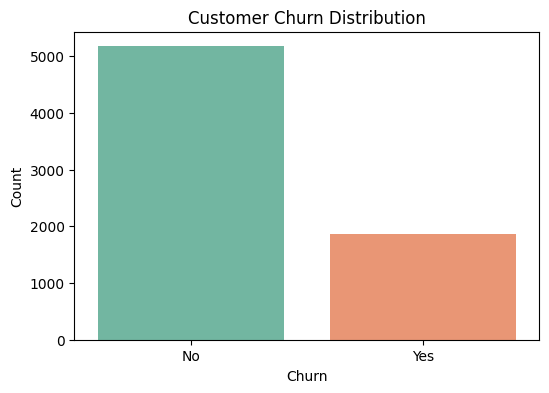

In [13]:
# plotting it on barplot
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

#### Univariate Analysis

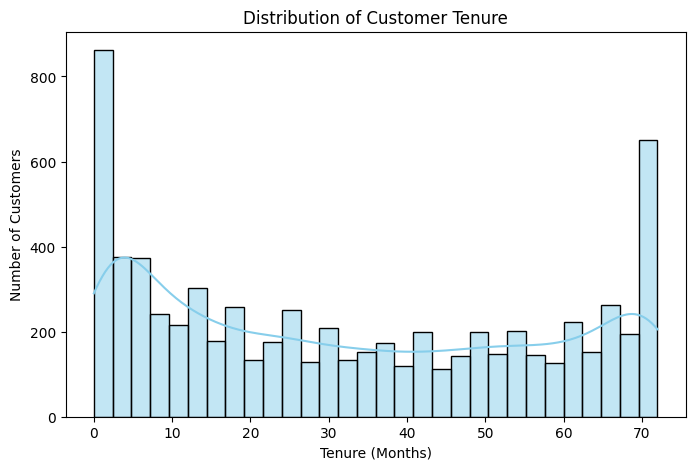

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='tenure', bins=30, kde=True, color='skyblue')
plt.title('Distribution of Customer Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.show()

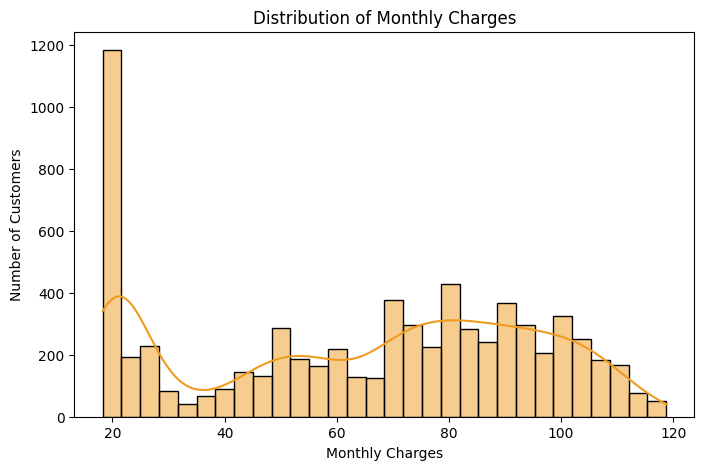

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='MonthlyCharges', bins=30, kde=True, color='#ef9b20')
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')
plt.show()

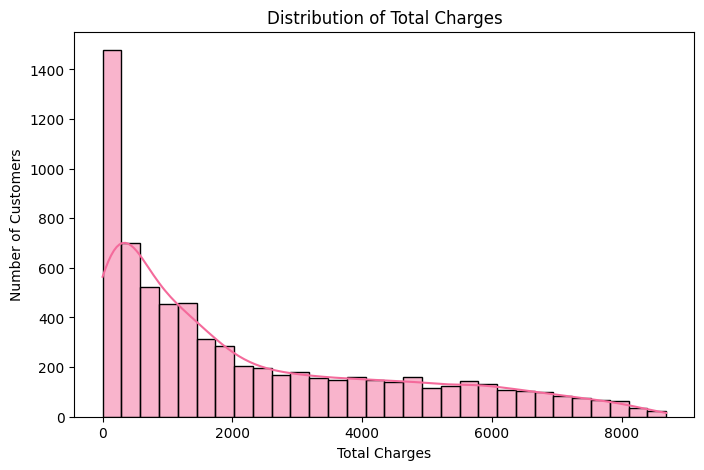

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='TotalCharges', bins=30, kde=True, color='#f46a9b')
plt.title('Distribution of Total Charges')
plt.xlabel('Total Charges')
plt.ylabel('Number of Customers')
plt.show()

#### Bivariate Analysis

C:\Users\shrut\AppData\Local\Temp\ipykernel_17104\222820338.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set2')


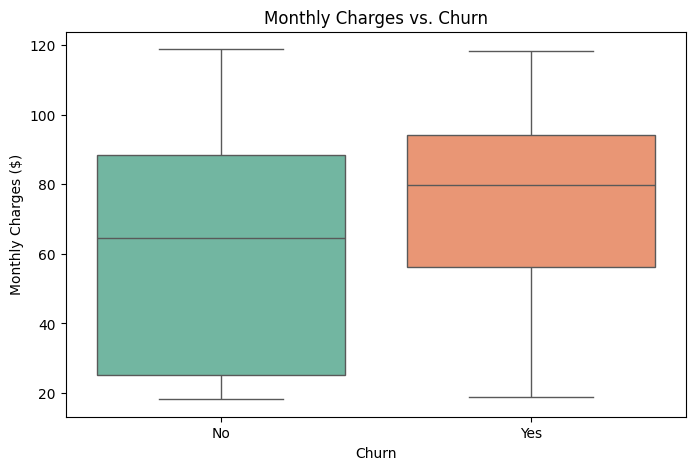

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set2')
plt.title('Monthly Charges vs. Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges ($)')
plt.show()

C:\Users\shrut\AppData\Local\Temp\ipykernel_17104\1746601592.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='TotalCharges', palette='Set2')


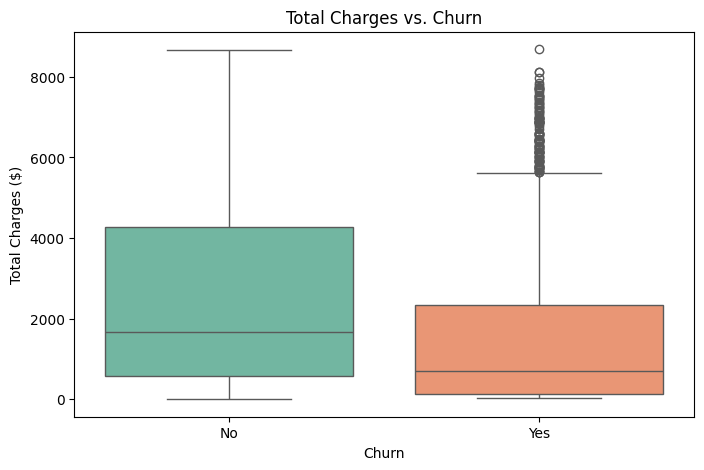

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Churn', y='TotalCharges', palette='Set2')
plt.title('Total Charges vs. Churn')
plt.xlabel('Churn')
plt.ylabel('Total Charges ($)')
plt.show()

C:\Users\shrut\AppData\Local\Temp\ipykernel_17104\437816165.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='tenure', palette='Set2')


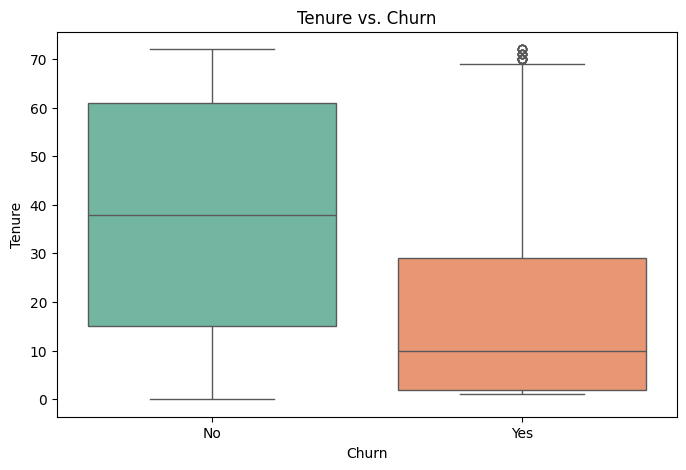

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Churn', y='tenure', palette='Set2')
plt.title('Tenure vs. Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure')
plt.show()

#### Correlations and Multicollinearity

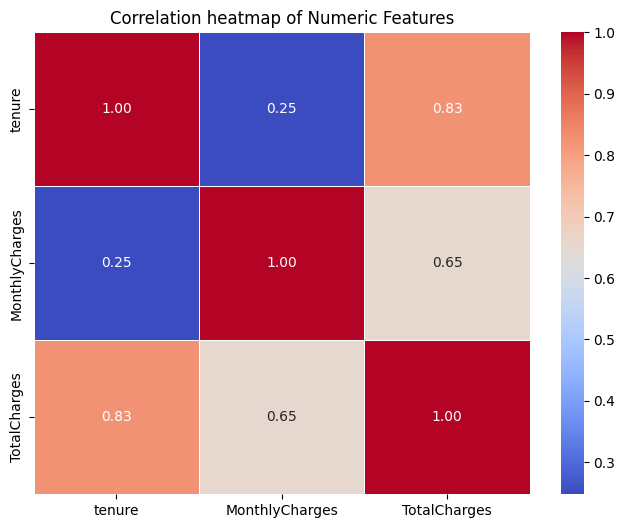

In [20]:
# isolate the numerical cols
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
corr_matrix = df[numeric_cols].corr()

# plot the heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidth=0.5)
plt.title('Correlation heatmap of Numeric Features')
plt.show()

we have multicolinearity in data...since TotalCharges = MonthlyCharges*tenure, it's not giving our model much new info

## Feature Engineering

In [21]:
# making tenure buckets
bin_edges = [-1, 12, 60, 100]
bin_labels = ['New (0-12m)', 'Established (13-60m)', 'Veteran(60m+)']

# create the new column
df['Tenure_Bucket'] = pd.cut(df['tenure'], bins=bin_edges, labels=bin_labels)

# check our work
df['Tenure_Bucket'].value_counts()

Tenure_Bucket
Established (13-60m)    3450
New (0-12m)             2186
Veteran(60m+)           1407
Name: count, dtype: int64

In [22]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Tenure_Bucket
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,New (0-12m)
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,Established (13-60m)
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,New (0-12m)
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,Established (13-60m)
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,New (0-12m)


In [23]:
# Grab all the text and category columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

# print their names and no of categories
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique values -> {df[col].unique()}")

customerID: 7043 unique values -> ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender: 2 unique values -> ['Female' 'Male']
Partner: 2 unique values -> ['Yes' 'No']
Dependents: 2 unique values -> ['No' 'Yes']
PhoneService: 2 unique values -> ['No' 'Yes']
MultipleLines: 3 unique values -> ['No phone service' 'No' 'Yes']
InternetService: 3 unique values -> ['DSL' 'Fiber optic' 'No']
OnlineSecurity: 3 unique values -> ['No' 'Yes' 'No internet service']
OnlineBackup: 3 unique values -> ['Yes' 'No' 'No internet service']
DeviceProtection: 3 unique values -> ['No' 'Yes' 'No internet service']
TechSupport: 3 unique values -> ['No' 'Yes' 'No internet service']
StreamingTV: 3 unique values -> ['No' 'Yes' 'No internet service']
StreamingMovies: 3 unique values -> ['No' 'Yes' 'No internet service']
Contract: 3 unique values -> ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: 2 unique values -> ['Yes' 'No']
PaymentMethod: 4 unique values -> ['Elect

In [24]:
# 1. Drop the customerID column
df = df.drop('customerID', axis=1)

# Map Churn to 1's and 0's
df['Churn'] = df['Churn'].map({'Yes' : 1, 'No' : 0})

# verify changes
print('Columns left : ', df.shape[1])
print("New Churn values:", df['Churn'].unique())

Columns left :  21
New Churn values: [0 1]


In [25]:
df_encoded = pd.get_dummies(df, drop_first=True)

# checking how many cols we have now
print('New Data Shape : ', df_encoded.shape)
df_encoded.head()

New Data Shape :  (7043, 33)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Tenure_Bucket_Established (13-60m),Tenure_Bucket_Veteran(60m+)
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,True,False,True,False,False,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,True,False,False,False,False,True,True,False
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,True,False,False,True,False,False
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,True,False,False,False,False,False,True,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,True,False,True,False,False,False


In [26]:
# Save the cleaned and encoded data to a new CSV file
df_encoded.to_csv('../data/telco_churn_cleaned.csv', index=False)
print('Cleaned data successfully saved :)')

Cleaned data successfully saved :)
